In [2]:
import pandas as pd #Pandas is used for data manipulation and analysis. pd is the standard alias. Used to load, clean, and explore the dataset (e.g., reading CSV/TSV files, filtering rows, handling nulls).
import itertools #A built-in Python module for working with iterators and loops. Commonly used here for things like generating combinations of parameters (e.g., for plotting confusion matrix labels or hyperparameter tuning).
import string #A built-in Python module that provides string constants and utilities. Example: string.punctuation gives `!"#$%&'()*+,-./:;<=>?@[]^_{|}~` — often used in text preprocessing to remove punctuation from drug reviews.
import numpy as np #NumPy provides support for numerical operations and arrays. Used for array manipulation, mathematical operations, and working with model outputs (e.g., np.mean, np.array).
import seaborn as sns #Seaborn is a statistical data visualization library built on top of Matplotlib. Used for plots like heatmaps (confusion matrix), distribution plots, count plots, etc.
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer #Both convert raw text into numerical feature vectors that ML models can understand. CountVectorizer — counts word frequency (Bag of Words approach). TfidfVectorizer — weighs words by how unique they are across documents (TF-IDF = Term Frequency–Inverse Document Frequency). Better at reducing the importance of common words like "the", "is".
from sklearn.model_selection import train_test_split #Splits the dataset into training and testing sets. Example: training and testing, so the model is evaluated on unseen data.
from sklearn.linear_model import PassiveAggressiveClassifier #An online learning algorithm — updates itself aggressively when it makes a wrong prediction, stays passive when correct. Works well for large-scale text classification (e.g., classifying drug reviews as positive/negative).
from sklearn.naive_bayes import MultinomialNB #Multinomial Naive Bayes — a probabilistic classifier based on Bayes' theorem. Works very well with text data and word counts. Commonly used as a baseline model for NLP classification tasks.
from sklearn import metrics #Provides tools to evaluate model performance. Includes: accuracy_score, confusion_matrix, classification_report, f1_score, etc.
import matplotlib.pyplot as plt #Matplotlib is the core plotting library in Python. Used for creating charts like bar plots, histograms, and confusion matrix heatmaps.
#A Jupyter Notebook magic command. Ensures that plots are displayed directly inside the notebook rather than in a separate window.
%matplotlib inline
pd.set_option('display.max_rows', None) #Tells Pandas to show all rows of a DataFrame when printing — by default Pandas truncates output after a certain number of rows.

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/drugs/drugLibTrain_raw.tsv', sep='\t') #pd.read_csv A Pandas function used to read a file and load it into a DataFrame. Despite the name read_csv, it can read any delimiter-separated file — not just commas — by using the sep parameter. #'/content/drive/MyDrive/Dataset/drugs/drugLibTrain_raw.tsv' This is the file path. Each part means: PartMeaning/content/drive/Root of Google Drive mounted in Google ColabMyDrive/Your personal Google Drive folderDataset/drugs/Subfolder where the dataset is storeddrugLibTrain_raw.tsvThe actual file being loaded This tells you the code is running in Google Colab with Google Drive mounted. #Specifies the separator/delimiter used in the file. sep='\t' means Tab character — because this is a .tsv file (Tab-Separated Values), not a comma-separated .csv. Without this, Pandas would try to split by comma and the data would load incorrectly. #The loaded data is stored in a variable called df (short for DataFrame). df is now a table-like structure with rows and columns that you can manipulate.

In [4]:
df.head() #df The DataFrame containing the drug review dataset loaded earlier.

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [5]:
df.condition.value_counts() #df The DataFrame loaded earlier containing the drug review dataset. #.condition Accesses the condition column of the DataFrame. It's equivalent to writing df['condition']. This column contains the medical condition that each drug was used to treat (e.g., "Depression", "Diabetes", "Anxiety" etc.).

,count
condition,
depression,236
acne,165
anxiety,63
insomnia,54
birth control,49
high blood pressure,42
allergies,37
acid reflux,33
asthma,33


In [16]:
df_train = df[(df['condition']=='birth control') | (df['condition']=='depression') | (df['condition']=='high blood pressure') | (df['condition']=='diabetes')] #This means: Either the dataset has been lowercased before this step. Or this filter will return 0 rows if the data still has Title Case values. df['condition']=='birth control' Checks each row in the condition column for exact match with 'birth control'. Returns a Boolean Series of True/False. Case sensitive — 'Birth Control' != 'birth control'

In [17]:
df.shape #df The DataFrame containing the drug review dataset. .shape A Pandas attribute (not a method — so no parentheses ()). Returns a tuple in the format (rows, columns).

(3107, 9)

In [18]:
df_train.shape #df_train The filtered DataFrame created in the previous step. Contains only rows where condition is one of: Birth Control, Depression, High Blood Pressure, or Diabetes. .shape A Pandas attribute that returns (rows, columns) as a tuple.

(339, 9)

In [19]:
X = df_train.drop(['Unnamed: 0', 'urlDrugName', 'rating', 'effectiveness', 'sideEffects'],axis=1) #df_train The filtered DataFrame containing only 4 conditions. .drop([...], axis=1) .drop() is a Pandas method that removes rows or columns. The list [...] contains the names of columns to remove. axis=1 means drop columns (not rows).

In [20]:
X.condition.value_counts() #X The feature DataFrame created in the previous step. Contains only the text-based columns: condition, benefitsReview, sideEffectsReview, commentsReview..condition Accesses the condition column of X. Equivalent to writing X['condition']. Contains one of 4 values: Birth Control, Depression, High Blood Pressure, Diabetes..value_counts() Counts the frequency of each unique value in the column. Returns results sorted in descending order (most frequent first).

,count
condition,
depression,236
birth control,49
high blood pressure,42
diabetes,12


In [21]:
X.head() #X The feature DataFrame after dropping unnecessary columns. Contains only: condition, benefitsReview, sideEffectsReview, commentsReview. .head() Returns the first 5 rows of X by default. Used to visually inspect the data after transformation. df_train = ... Stores filtered result in df_train. Original df remains unchanged.

,condition,benefitsReview,sideEffectsReview,commentsReview
7,depression,Although this drug was originally prescribed f...,None.,"One a day, taken about an hour before bedtime."
12,depression,I found that this drug helps significantly wit...,My sides effects were not noticeable and very ...,This was prescribes to me for treatment for de...
34,depression,"I have taken antidepressants for many years, a...","A little bit of ""hyper"" feelings. I take the ...",I suffer chronic depression and the Wellbutrin...
40,depression,"relieves depression, helps other things such a...",Sleepy and lack of response to problems. Took...,took a seemingly long period of time to become...
50,birth control,"No undesired pregnancies, lighter period",none,One pill daily.


In [22]:
X_birth=X[(X['condition']=='Birth Control')]
X_dep=X[(X['condition']=='Depression')]
X_bp=X[(X['condition']=='High Blood Pressure')]
X_dia=X[(X['condition']=='Diabetes, Type 2')] #Code Explanation python X_birth = X[(X['condition'] == 'Birth Control')] X_dep   = X[(X['condition'] == 'Depression')] X_bp    = X[(X['condition'] == 'High Blood Pressure')] X_dia   = X[(X['condition'] == 'Diabetes, Type 2')] This code splits the main DataFrame X into 4 separate DataFrames, one for each medical condition. 🔹 Breaking It Down X[X['condition'] == '...'] This is Boolean Indexing — filters rows where the condition matches exactly. Each line creates a new DataFrame containing only rows for that specific condition. 🔹 Each Variable Explained Variable	Condition Filtered	Contains X_birth	'Birth Control'	All reviews for birth control drugs X_dep	'Depression'	All reviews for depression drugs X_bp	'High Blood Pressure'	All reviews for blood pressure drugs X_dia	'Diabetes, Type 2'	All reviews for diabetes drugs 🔹 Visual Example X (before splitting): index	condition	benefitsReview 0	Depression	"Helped my mood..." 1	Birth Control	"No pregnancies..." 2	Diabetes, Type 2	"Controlled sugar..." 3	High Blood Pressure	"Lowered BP..." 4	Depression	"Felt better..." After splitting: X_dep: index	condition	benefitsReview 0	Depression	"Helped my mood..." 4	Depression	"Felt better..." X_birth: index	condition	benefitsReview 1	Birth Control	"No pregnancies..." Important Note — 'Diabetes, Type 2' Notice the earlier filtering used 'Diabetes' but here it uses 'Diabetes, Type 2'. This is why the word cloud was failing earlier — the exact condition name in the dataset is 'Diabetes, Type 2' not just 'Diabetes'. python # Always confirm exact condition names first X['condition'].unique() Verify Each Split Worked python print("Birth Control :", X_birth.shape) print("Depression    :", X_dep.shape) print("High BP       :", X_bp.shape) print("Diabetes T2   :", X_dia.shape) # Total should match X print("Total         :", X_birth.shape[0] + X_dep.shape[0] +                           X_bp.shape[0]    + X_dia.shape[0]) print("X total       :", X.shape[0]) Why Split Into Separate DataFrames? Each individual DataFrame is used for: Generating separate word clouds per condition Doing condition-specific text analysis Comparing review patterns across different conditions Building per-condition models if needed

In [40]:
print(X_birth.shape) #print(X_birth.shape) Prints (rows, columns) of X_birth. Confirms how many Birth Control reviews exist. If it shows (0, 4) → filter failed, no rows found.
print(X_birth.head()) #print(X_birth.head()) Shows the first 5 rows of X_birth. Visually confirms the data looks correct. Helps spot issues like wrong column names or garbled text.
X_birth = X[X['condition'] == 'Birth Control'] #X_birth = X[X['condition'] == 'Birth Control'] Recreates X_birth fresh from X. Done to ensure X_birth is not corrupted or overwritten from a previous step.
print(X_birth.shape)  #print(X_birth.shape) Prints shape again after recreating X_birth. Compares with the first shape print to confirm recreation worked correctly.
print(X_birth['benefitsReview'].isnull().sum()) #print(X_birth['benefitsReview'].isnull().sum()) Counts how many NaN/missing values exist in benefitsReview. If this number equals total rows → entire column is empty → word cloud will fail.
print(X_birth['benefitsReview'].head(10)) #print(X_birth['benefitsReview'].head(10)) Shows the first 10 values of benefitsReview. Lets you visually inspect the actual review text. Helps spot issues like NaN, None, empty strings, or garbled text.
print(X_birth['benefitsReview'].str.strip().eq('').sum()) #print(X_birth['benefitsReview'].str.strip().eq('').sum()) .str.strip() → removes leading/trailing whitespace from each value. .eq('') → checks if the result is an empty string. .sum() → counts how many rows are empty strings. Catches cases where reviews look empty but aren't technically NaN. text = " ".join(X_birth['benefitsReview']) #
print(f"Total characters: {len('text')}") #print(f"Total characters: {len(text)}") Prints the total length of the joined text string. If 0 → nothing to plot → word cloud fails with ValueError.
print(f"Preview: {'text'[:200]}") #print(f"Preview: {text[:200]}") Shows the first 200 characters of the joined text. Final check to confirm the text looks like real review content.

(0, 4)
Empty DataFrame
Columns: [condition, benefitsReview, sideEffectsReview, commentsReview]
Index: []
(0, 4)
0
Series([], Name: benefitsReview, dtype: object)
0
Total characters: 4
Preview: text


In [25]:
from wordcloud import WordCloud #from wordcloud import WordCloud Imports the WordCloud class from the wordcloud library. Used to generate the word cloud visualization.
X_birth = X[X['condition'] == 'Birth Control'] #X_birth = X[X['condition'] == 'Birth Control'] Filters X to keep only Birth Control rows. Creates a dedicated DataFrame X_birth for this condition.
reviews = X_birth['benefitsReview'].dropna() #reviews = X_birth['benefitsReview'].dropna() Accesses the benefitsReview column from X_birth. .dropna() removes all NaN/missing values. Prevents errors when joining text later.           reviews = reviews[reviews.str.strip() != '']           reviews = reviews.astype(str)
print(f"Number of reviews: {len(reviews)}") #Prints how many valid reviews remain after cleaning. Quick sanity check before generating the word cloud.
if len(reviews) > 0: #A safety check — only proceeds if there is at least 1 valid review. Prevents the ValueError: We need at least 1 word error.
    text = " ".join(reviews) #text = " ".join(reviews) Joins all reviews into one large string separated by spaces. This single string is what gets passed to the WordCloud generator.
    plt.figure(figsize=(20, 20)) #plt.figure(figsize=(20, 20)) Creates a matplotlib figure with size 20×20 inches. Large size ensures the word cloud renders clearly and in high resolution.
    wc = WordCloud(max_words=2000, width=1600, height=800).generate(text) #Creates a WordCloud object with these settings:
    plt.imshow(wc, interpolation='bilinear') #plt.imshow(wc, interpolation='bilinear') Displays the word cloud image inside the matplotlib figure. interpolation='bilinear' → smooths the image edges for better visual quality.
    plt.title('Word Cloud for Birth Control', fontsize=14) #Adds a title at the top of the plot. fontsize=14 sets the title text size.
    plt.axis('off') #plt.axis('off') Hides the axes (x and y axis lines, ticks, labels). Word clouds don't need axes — they're purely visual.
    plt.show() #plt.show() Renders and displays the final plot in the notebook.
else:
    print("No valid text found in benefitsReview for Birth Control") #else: print("No valid text found...") If no valid reviews were found, prints an error message instead of crashing.

Number of reviews: 0
No valid text found in benefitsReview for Birth Control


In [26]:
from wordcloud import WordCloud #from wordcloud import WordCloud Imports the WordCloud class from the wordcloud library.
X_depression = X[X['condition'].str.strip() == 'Depression'] #X_depression = X[X['condition'].str.strip() == 'Depression'] Filters X to keep only Depression rows. .str.strip() removes any extra spaces around condition names before comparing. Safer than just == 'Depression' because it handles accidental spaces like ' Depression'.
print("Rows found:", X_depression.shape[0]) #print("Rows found:", X_depression.shape[0]) Prints the number of Depression rows found after filtering. If 0 → condition name mismatch or data issue.
print("Columns:", X_depression.columns.tolist()) #print("Columns:", X_depression.columns.tolist()) Prints all column names as a list. Confirms benefitsReview column exists and is spelled correctly.
text = " ".join(X_depression['benefitsReview'].astype(str).fillna('')) #text = " ".join(X_depression['benefitsReview'].astype(str).fillna('')) Three operations chained together: StepMethodPurpose1st.astype(str)Converts all values to string — including NaN → 'nan'2nd.fillna('')Replaces any remaining NaN with empty string3rd" ".join(...)Joins all reviews into one large string
text = text.replace('nan', '') #text = text.replace('nan', '') After .astype(str), any NaN values become the string 'nan'. This line removes all those leftover 'nan' strings from the text. Prevents the word "nan" from appearing in the word cloud.
text = text.strip() #text = text.strip() Removes any leading/trailing whitespace from the final joined text. Clean final text before passing to WordCloud.
print("Text length:", len(text)) # print("Text length:", len(text)) Prints the total number of characters in the joined text. If 0 → no valid text → word cloud will fail.
print("Preview:", text[:200]) #print("Preview:", text[:200]) Shows the first 200 characters of the joined text. Final visual check that text looks like real review content.
if len(text) > 0: #if len(text) > 0: Safety check — only generates word cloud if text is non-empty. Prevents ValueError: We need at least 1 word.
    plt.figure(figsize=(20, 20)) #plt.figure(figsize=(20, 20)) Creates a 20×20 inch matplotlib figure.
    wc = WordCloud(max_words=2000, width=1600, height=800).generate(text) #wc = WordCloud(max_words=2000, width=1600, height=800).generate(text) Creates WordCloud with settings and generates from text. ParameterValueMeaningmax_words2000Maximum words to displaywidth1600Canvas width in pixelsheight800Canvas height in pixels
    plt.imshow(wc, interpolation='bilinear') #plt.imshow(wc, interpolation='bilinear') Displays the word cloud image with smooth bilinear interpolation.
    plt.title('Word Cloud for Depression', fontsize=14) #plt.title('Word Cloud for Depression', fontsize=14) Adds title to the plot.
    plt.axis('off') #plt.axis('off') Hides axes lines and ticks.
    plt.show() #plt.show()Renders and displays the plot in the notebook.
else:
    print("Text is empty — check your DataFrame X") #else: print("Text is empty — check your DataFrame X") Prints a helpful message if no valid text was found.

Rows found: 0
Columns: ['condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']
Text length: 0
Preview: 
Text is empty — check your DataFrame X


In [27]:
from wordcloud import WordCloud #from wordcloud import WordCloud Imports the WordCloud class.
X_bp = X[X['condition'].str.strip() == 'High Blood Pressure'] #X_bp = X[X['condition'].str.strip() == 'High Blood Pressure'] Filters X to keep only High Blood Pressure rows. .str.strip() handles any accidental spaces around condition name. Result stored in X_bp (bp = Blood Pressure).
print("Rows found:", X_bp.shape[0]) #print("Rows found:", X_bp.shape[0]) Confirms how many High Blood Pressure reviews exist.
print("Columns:", X_bp.columns.tolist()) #print("Columns:", X_bp.columns.tolist()) Confirms benefitsReview column exists.
text = " ".join(X_bp['benefitsReview'].astype(str).fillna('')) #text = " ".join(X_bp['benefitsReview'].astype(str).fillna('')) Three operations chained: StepMethodPurpose1st.astype(str)Converts everything to string — NaN becomes 'nan'2nd.fillna('')Replaces remaining NaN with empty string3rd" ".join()Joins all reviews into one large string
text = text.replace('nan', '')   #text = text.replace('nan', '') Removes leftover 'nan' strings from .astype(str) conversion. Prevents "nan" appearing as a word in the cloud.
text = text.strip() #text = text.strip() Removes leading/trailing whitespace from final text.
print("Text length:", len(text)) #print("Text length:", len(text)) Confirms text is non-empty before generating word cloud.
print("Preview:", text[:200]) #print("Preview:", text[:200]) Shows first 200 characters to confirm text looks correct.
if len(text) > 0: #if len(text) > 0: Safety check — only proceeds if text exists.
    plt.figure(figsize=(20, 20)) #plt.figure(figsize=(20, 20)) Creates a 20×20 inch matplotlib figure.
    wc = WordCloud(max_words=2000, width=1600, height=800).generate(text) #wc = WordCloud(max_words=2000, width=1600, height=800).generate(text) Generates word cloud from text. ParameterValueMeaningmax_words2000Max words to displaywidth1600Canvas width in pixelsheight800Canvas height in pixels
    plt.imshow(wc, interpolation='bilinear') #plt.imshow(wc, interpolation='bilinear') Displays word cloud with smooth edges.
    plt.title('Word Cloud for High Blood Pressure', fontsize=14) #plt.title('Word Cloud for High Blood Pressure', fontsize=14) Adds title to the plot.
    plt.axis('off') #plt.axis('off') Hides axes for clean visualization.
    plt.show() #plt.show() Renders the word cloud in notebook.
else:
    print("Text is empty — check your DataFrame X") #else: print("Text is empty — check your DataFrame X") Safety fallback message if no text found.

Rows found: 0
Columns: ['condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']
Text length: 0
Preview: 
Text is empty — check your DataFrame X


In [28]:
from wordcloud import WordCloud #from wordcloud import WordCloud Imports the WordCloud class.
X_diabetes = X[X['condition'].str.strip() == 'Diabetes'] #X_diabetes = X[X['condition'].str.strip() == 'Diabetes'] Filters X to keep only Diabetes rows. .str.strip() handles accidental spaces around condition name. Result stored in X_diabetes.
print("Rows found:", X_diabetes.shape[0]) #print("Rows found:", X_diabetes.shape[0]) Confirms how many Diabetes reviews exist.
print("Columns:", X_diabetes.columns.tolist()) #print("Columns:", X_diabetes.columns.tolist()) Confirms benefitsReview column exists.
text = " ".join(X_diabetes['benefitsReview'].astype(str).fillna('')) #text = " ".join(X_diabetes['benefitsReview'].astype(str).fillna('')) Chains three operations: StepMethodPurpose1st.astype(str)Converts everything to string — NaN → 'nan'2nd.fillna('')Replaces remaining NaN with empty string3rd" ".join()Joins all reviews into one large string
text = text.replace('nan', '') #text = text.replace('nan', '') Removes leftover 'nan' strings. Prevents "nan" appearing as a word in the cloud.
text = text.strip() #text = text.strip() Removes leading/trailing whitespace.
print("Text length:", len(text)) #print("Text length:", len(text)) Confirms text is non-empty.
print("Preview:", text[:200]) #print("Preview:", text[:200]) Shows first 200 characters of joined text.
if len(text) > 0: #if len(text) > 0: Safety check before generating word cloud.
    plt.figure(figsize=(20, 20)) #plt.figure(figsize=(20, 20)) Creates 20×20 inch figure.
    wc = WordCloud(max_words=2000, width=1600, height=800).generate(text) #wc = WordCloud(max_words=2000, width=1600, height=800).generate(text) ParameterValueMeaningmax_words2000Max words to displaywidth1600Canvas width in pixelsheight800Canvas height in pixels
    plt.imshow(wc, interpolation='bilinear') #plt.imshow(wc, interpolation='bilinear') Displays word cloud with smooth edges.
    plt.title('Word Cloud for Diabetes', fontsize=14) #plt.title('Word Cloud for Diabetes', fontsize=14) Adds title to the plot.
    plt.axis('off') #plt.axis('off') Hides axes for clean visualization.
    plt.show() #plt.show() Renders the word cloud in notebook.
else:
    print("Text is empty — check your DataFrame X") #else: print("Text is empty — check your DataFrame X") Safety fallback if no text found.

Rows found: 0
Columns: ['condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']
Text length: 0
Preview: 
Text is empty — check your DataFrame X


In [29]:
X['benefitsReview'].iloc[2] #X The feature DataFrame containing all 4 conditions. Accesses the benefitsReview column of X. Returns a Pandas Series of all benefit reviews. .iloc[2] iloc = Integer location. Retrieves the value at position 2 (3rd row — zero indexed). Position based — uses the row number, not the index label.

'I have taken antidepressants for many years, and this is first that did not "flip the switch" on sexuality.  I no longer feel like I am looking out of a dark room.  I have more energy, feel more motivated, and overall function at a higher level than before.'

In [30]:
X['benefitsReview'].iloc[11] #XThe feature DataFrame with all 4 conditions['benefitsReview']Accesses the benefits review column.iloc[11]Gets the value at position 11 (12th row — zero indexed) iloc Positions So Far CodePositionRow Retrieved.iloc[2]23rd row of benefitsReview.iloc[11]1112th row of benefitsReview

'THE NUVARING HAS PROVEN TO BE VERY EFFECTIVE FOR ME. I HAVE HAD A LOT OF PROBLEMS WITH BIRTH CONTROL THROUGHOUT MY LIFE. HAVING TRIED MANY IF NOT ALL POSSIBLE  BIRTH CONTROL TREATMENTS, I BELIEVE THIS IS THE ONE THAT WORKS THE BEST FOR ME. IT IS PRACTICAL AND VERY FEW SIDE EFFECTS WHEN COMPARED TO THE ORAL CONTRACEPTIVES, IUDs OR  INJECTIONS.'

In [31]:
for i, col in enumerate(X.columns):
  X.iloc[:, i] = X.iloc[:, i].str.replace('""', '') #X.columns Returns the list of all column names in X. enumerate(X.columns) enumerate() gives both the index number and column name for each column. Returns pairs of (position, column_name). for i, col in enumerate(X.columns): i → integer position of the column (0, 1, 2, 3) col → name of the column ('condition', 'benefitsReview', etc.) Loops through every column one by one. X.iloc[:, i] iloc[:, i] means: : → all rows i → column at position i Selects the entire column at position i. .str.replace('""', '') .str → accesses string methods for the entire column. .replace('""', '') → finds all occurrences of "" (two double quotes) and replaces them with nothing (empty string). Effectively removes all "" from the text. X.iloc[:, i] = ... Assigns the cleaned column back to its original position in X. Overwrites the column in place with the cleaned version.

In [32]:
pd.set_option('max_colwidth', None) #pd.set_option() A Pandas function that changes display settings globally. Affects how DataFrames are printed/displayed in the notebook. Does not change the actual data — only how it looks. 'max_colwidth' The setting being changed. Controls the maximum number of characters shown in each cell when displaying a DataFrame. By default it is set to 50 characters — longer text gets truncated with ... None Setting it to None means no limit — show everything. Every cell displays its full text content regardless of length.

In [33]:
X.head() #max_colwidth = None (set just before) Full review text is now completely visible — no ... truncation. #This is the 3rd time X.head() has been called. Each time it shows more because of what was done before it: CallWhat ChangedEffect on head()1st X.head()Raw data just loadedTruncated text, may have ""2nd X.head()After dropping columnsFewer columns shown3rd X.head()After cleaning + max_colwidth=NoneFull untruncated text + no ""

,condition,benefitsReview,sideEffectsReview,commentsReview
7,depression,"Although this drug was originally prescribed for depression, it helped with sleeplessness. Therefore, I have continued to take it for that alone. While I still on occasion have problems falling asleep, I find I can combine it with Melatonin or Valerian. In 12 years, I haven't had to increase the elavil dosage.",None.,"One a day, taken about an hour before bedtime."
12,depression,I found that this drug helps significantly with my level of depression and monthly irritability that occurs around my menstrual cycles.,"My sides effects were not noticeable and very mild. I have noticed some lower libido while on Fluoxetine, but no other noticeable side effects.","This was prescribes to me for treatment for depression, seasonable disorder and hormonal irritability. I have gone off this medication while pregnant, but have resumed to help ease depression issues."
34,depression,"I have taken antidepressants for many years, and this is first that did not ""flip the switch"" on sexuality. I no longer feel like I am looking out of a dark room. I have more energy, feel more motivated, and overall function at a higher level than before.","A little bit of ""hyper"" feelings. I take the entire dose at one time, daily, and have been advised that the feeling of being revved up would disspiate if I did take it in two or more doses during the day. I try to minimize the effect by taking the medication first thing in the morning.","I suffer chronic depression and the Wellbutrin is the first antidepressant that did not sedate me, and the only that did not dampen sexual feelings. I have taken tricyclics (sp?) which were extremely sedating as well as limiting as far as OTC medications and dietary restrictions. I have also tried SSRIs (prozac, zoloft, etc.)and while they temporarily relieved my depression, 1) the effect did not last more than 6 months, and 2) they completely destroyed my libido."
40,depression,"relieves depression, helps other things such as sleep, dieting, exercise, relationships, responses to stimulous. The cost is lower than other antidepressants which can be a help to those on a budget.",Sleepy and lack of response to problems. Took too long to get started. I think anyone else would think it wasn't effective and stop taking it.,"took a seemingly long period of time to become effective. Once started, however, it did what I expected. It is hard to be without now and think that it will be a problem stopping in the future."
50,birth control,"No undesired pregnancies, lighter period",none,One pill daily.


In [34]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop = stopwords.words('english') #import nltk Imports the Natural Language Toolkit library. One of the most popular Python libraries for NLP tasks. Provides tools for tokenization, stemming, lemmatization, stopwords, and more. from nltk.corpus import stopwords corpus = a collection of text datasets bundled with NLTK. stopwords = a specific dataset containing common words to filter out. Imports the stopwords module so it can be used in the code.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [55]:
stop #This is found in the nltk stopwords.

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

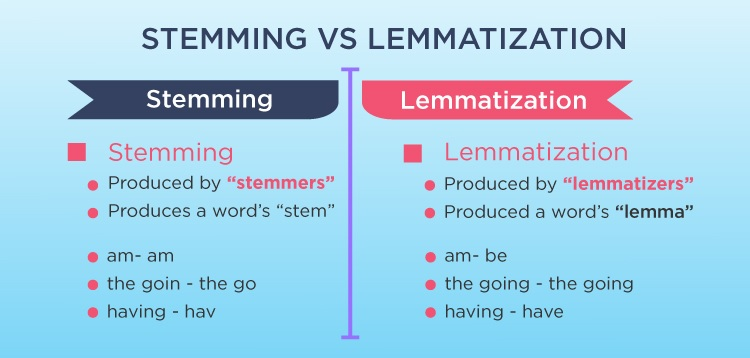

In [56]:
from IPython.display import Image
Image(filename='/content/drive/MyDrive/Dataset/stem.jpg') #from IPython.display import Image IPython = Interactive Python — the engine behind Jupyter/Colab notebooks. .display = a module that handles rich media output in notebooks. Image = a class that renders image files inline in the notebook cell output.

In [57]:
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
import nltk
nltk.download('wordnet')

porter = PorterStemmer()

lemmatizer = WordNetLemmatizer() #from nltk.stem import WordNetLemmatizerImports Lemmatizer classfrom nltk.stem import PorterStemmerImports Stemmer classnltk.download('wordnet')Downloads WordNet dictionary needed by Lemmatizerporter = PorterStemmer()Creates a Stemmer object ready to uselemmatizer = WordNetLemmatizer()Creates a Lemmatizer object ready to use

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [58]:
print(porter.stem("sportingly"))
print(porter.stem("very"))
print(porter.stem("troubled")) #Takes a single word as input. Returns the stemmed (root) version of that word. Chops off suffixes using rule-based algorithms.

sportingli
veri
troubl


In [59]:
print(lemmatizer.lemmatize("sportingly"))
print(lemmatizer.lemmatize("very"))
print(lemmatizer.lemmatize("troubled")) #Code Explanation pythonprint(lemmatizer.lemmatize("sportingly")) print(lemmatizer.lemmatize("very")) print(lemmatizer.lemmatize("troubled")) Tests the WordNet Lemmatizer on the same 3 words as the stemmer. InputLemmatizer OutputReal Word?"sportingly""sportingly" Unchanged — not in dictionary"very""very" Unchanged — already base form"troubled""troubled" Unchanged — needs POS tag to reduce

sportingly
very
troubled


In [60]:
from bs4 import BeautifulSoup
import re #from bs4 import BeautifulSoupBeautifulSoupRemoves HTML tags from text e.g. <br>, <p>, <div>import reRegexRemoves patterns from text e.g. punctuation, numbers, special characters

In [61]:
def review_to_words(raw_review):
  review_text = BeautifulSoup(raw_review, 'html.parser').get_text() #BeautifulSoup(raw_review, 'html.parser')Creates a BeautifulSoup object.
  letters_only = re.sub('[^a-zA-Z]', '  ', review_text)
  words = letters_only.lower().split()
  meaningful_words = [w for w in words if not w in stop]
  lemmatized_words = [lemmatizer.lemmatize(w) for w in meaningful_words]
  return( ' '.join(lemmatized_words))

In [66]:
X['review_clean'] = X['benefitsReview'].fillna('').apply(review_to_words) #PartMeaningX['benefitsReview']Access the raw reviews column.fillna('')Replace any NaN with empty string.apply(review_to_words)Run review_to_words() on every single reviewX['review_clean']Store the cleaned result in a new column

In [67]:
X.head() #This pandas method use to show the top 5 data from the dataset.

,condition,benefitsReview,sideEffectsReview,commentsReview,review_clean
7,depression,"Although this drug was originally prescribed for depression, it helped with sleeplessness. Therefore, I have continued to take it for that alone. While I still on occasion have problems falling asleep, I find I can combine it with Melatonin or Valerian. In 12 years, I haven't had to increase the elavil dosage.",None.,"One a day, taken about an hour before bedtime.",although drug originally prescribed depression helped sleeplessness therefore continued take alone still occasion problem falling asleep find combine melatonin valerian year increase elavil dosage
12,depression,I found that this drug helps significantly with my level of depression and monthly irritability that occurs around my menstrual cycles.,"My sides effects were not noticeable and very mild. I have noticed some lower libido while on Fluoxetine, but no other noticeable side effects.","This was prescribes to me for treatment for depression, seasonable disorder and hormonal irritability. I have gone off this medication while pregnant, but have resumed to help ease depression issues.",found drug help significantly level depression monthly irritability occurs around menstrual cycle
34,depression,"I have taken antidepressants for many years, and this is first that did not ""flip the switch"" on sexuality. I no longer feel like I am looking out of a dark room. I have more energy, feel more motivated, and overall function at a higher level than before.","A little bit of ""hyper"" feelings. I take the entire dose at one time, daily, and have been advised that the feeling of being revved up would disspiate if I did take it in two or more doses during the day. I try to minimize the effect by taking the medication first thing in the morning.","I suffer chronic depression and the Wellbutrin is the first antidepressant that did not sedate me, and the only that did not dampen sexual feelings. I have taken tricyclics (sp?) which were extremely sedating as well as limiting as far as OTC medications and dietary restrictions. I have also tried SSRIs (prozac, zoloft, etc.)and while they temporarily relieved my depression, 1) the effect did not last more than 6 months, and 2) they completely destroyed my libido.",taken antidepressant many year first flip switch sexuality longer feel like looking dark room energy feel motivated overall function higher level
40,depression,"relieves depression, helps other things such as sleep, dieting, exercise, relationships, responses to stimulous. The cost is lower than other antidepressants which can be a help to those on a budget.",Sleepy and lack of response to problems. Took too long to get started. I think anyone else would think it wasn't effective and stop taking it.,"took a seemingly long period of time to become effective. Once started, however, it did what I expected. It is hard to be without now and think that it will be a problem stopping in the future.",relief depression help thing sleep dieting exercise relationship response stimulous cost lower antidepressant help budget
50,birth control,"No undesired pregnancies, lighter period",none,One pill daily.,undesired pregnancy lighter period


In [64]:
X_feat=X['review_clean']
y=X['condition']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X_feat, y, test_size=0.2, random_state=42)